In [1]:
import io
import os
import subprocess
import shutil
import zipfile
import requests
import rioxarray
import pyproj
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

proj_data_dir = pyproj.datadir.get_data_dir()
env = {**os.environ, "PROJ_DATA": proj_data_dir, "PROJ_LIB": proj_data_dir}

## download the "Gray Earth with Shaded Relief, Hypsography, Ocean Bottom, and Drainages" from Natural Earth

In [2]:
url = "https://naturalearth.s3.amazonaws.com/10m_raster/GRAY_HR_SR_OB_DR.zip"

In [3]:
response = requests.get(url, timeout=60)
response.raise_for_status()
print(f"Downloaded {len(response.content) / 1e6:.1f} MB")

Downloaded 91.7 MB


In [6]:
with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
    zf.extractall("GRAY_HR_SR_OB_DR")
    tif_path = next(f"GRAY_HR_SR_OB_DR/{n}" for n in zf.namelist() if n.endswith(".tif"))

print(f"Extracted: {tif_path}")
print(f"File size: {os.path.getsize(tif_path) / 1e6:.1f} MB")

Extracted: GRAY_HR_SR_OB_DR/GRAY_HR_SR_OB_DR.tif
File size: 233.4 MB


In [7]:
subprocess.run(["gdalinfo", tif_path], env=env, check=True)

Driver: GTiff/GeoTIFF
Files: GRAY_HR_SR_OB_DR/GRAY_HR_SR_OB_DR.tif
Size is 21600, 10800
Coordinate System is:
GEOGCRS["WGS 84",
    ENSEMBLE["World Geodetic System 1984 ensemble",
        MEMBER["World Geodetic System 1984 (Transit)"],
        MEMBER["World Geodetic System 1984 (G730)"],
        MEMBER["World Geodetic System 1984 (G873)"],
        MEMBER["World Geodetic System 1984 (G1150)"],
        MEMBER["World Geodetic System 1984 (G1674)"],
        MEMBER["World Geodetic System 1984 (G1762)"],
        MEMBER["World Geodetic System 1984 (G2139)"],
        MEMBER["World Geodetic System 1984 (G2296)"],
        ELLIPSOID["WGS 84",6378137,298.257223563,
            LENGTHUNIT["metre",1]],
        ENSEMBLEACCURACY[2.0]],
    PRIMEM["Greenwich",0,
        ANGLEUNIT["degree",0.0174532925199433]],
    CS[ellipsoidal,2],
        AXIS["geodetic latitude (Lat)",north,
            ORDER[1],
            ANGLEUNIT["degree",0.0174532925199433]],
        AXIS["geodetic longitude (Lon)",east,
     

CompletedProcess(args=['gdalinfo', 'GRAY_HR_SR_OB_DR/GRAY_HR_SR_OB_DR.tif'], returncode=0)

## now reproject to robinson with res=1km

In [8]:
global_hillshade_filename = "global_hillshade_robinson.tif"

In [10]:
subprocess.run([
    "gdalwarp",
    "-t_srs", "ESRI:54030",
    "-te_srs", "EPSG:4326",
    "-te", "-180", "-90", "180", "90",
    "-tr",    "1000", "1000",
    "-r",     "average",
    "-ot",    "Byte",
    "-of",    "COG",
    "-co",    "COMPRESS=LZW",
    "-co",    "BIGTIFF=IF_SAFER",
    tif_path,
    global_hillshade_filename,
], env=env, check=True)

Creating output file that is 34012P x 17250L.
0...10...20...30...40...50...60...70...80...90...100 - done in 00:01:20.


CompletedProcess(args=['gdalwarp', '-t_srs', 'ESRI:54030', '-te_srs', 'EPSG:4326', '-te', '-180', '-90', '180', '90', '-tr', '1000', '1000', '-r', 'average', '-ot', 'Byte', '-of', 'COG', '-co', 'COMPRESS=LZW', '-co', 'BIGTIFF=IF_SAFER', 'GRAY_HR_SR_OB_DR/GRAY_HR_SR_OB_DR.tif', 'global_hillshade_robinson.tif'], returncode=0)

In [11]:
print(f"Created: {global_hillshade_filename}")
print(f"File size: {os.path.getsize(global_hillshade_filename) / 1e6:.1f} MB")

Created: global_hillshade_robinson.tif
File size: 252.4 MB


In [12]:
subprocess.run(["gdalinfo", global_hillshade_filename], env=env, check=True)

Driver: GTiff/GeoTIFF
Files: global_hillshade_robinson.tif
Size is 34012, 17250
Coordinate System is:
PROJCRS["World_Robinson",
    BASEGEOGCRS["WGS 84",
        DATUM["World Geodetic System 1984",
            ELLIPSOID["WGS 84",6378137,298.257223563,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["Degree",0.0174532925199433]]],
    CONVERSION["World_Robinson",
        METHOD["Robinson"],
        PARAMETER["Longitude of natural origin",0,
            ANGLEUNIT["Degree",0.0174532925199433],
            ID["EPSG",8802]],
        PARAMETER["False easting",0,
            LENGTHUNIT["metre",1],
            ID["EPSG",8806]],
        PARAMETER["False northing",0,
            LENGTHUNIT["metre",1],
            ID["EPSG",8807]]],
    CS[Cartesian,2],
        AXIS["(E)",east,
            ORDER[1],
            LENGTHUNIT["metre",1]],
        AXIS["(N)",north,
            ORDER[2],
            LENGTHUNIT["metre",1]],
    USAGE[
        SCOPE["Not known

CompletedProcess(args=['gdalinfo', 'global_hillshade_robinson.tif'], returncode=0)

## try opening and plotting the hillshade

In [13]:
hillshade_da = rioxarray.open_rasterio("global_hillshade_robinson.tif",chunks="auto").squeeze()
hillshade_da

<xarray.DataArray (y: 17250, x: 34012)> Size: 587MB
dask.array<getitem, shape=(17250, 34012), dtype=uint8, chunksize=(11264, 11484), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 138kB 8.625e+06 8.624e+06 ... -8.623e+06 -8.624e+06
  * x            (x) float64 272kB -1.701e+07 -1.7e+07 ... 1.7e+07 1.701e+07
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_SOFTWARE:        Adobe Photoshop CS5 Macintosh
    TIFFTAG_DATETIME:        2012:07:20 09:39:49
    TIFFTAG_XRESOLUTION:     72
    TIFFTAG_YRESOLUTION:     72
    TIFFTAG_RESOLUTIONUNIT:  2 (pixels/inch)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0

In [14]:
hillshade_coarsened_da = hillshade_da.coarsen(x=10, y=10, boundary="trim").mean()
hillshade_coarsened_da

<xarray.DataArray (y: 1725, x: 3401)> Size: 47MB
dask.array<mean_agg-aggregate, shape=(1725, 3401), dtype=float64, chunksize=(1126, 1126), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 14kB 8.62e+06 8.61e+06 ... -8.61e+06 -8.62e+06
  * x            (x) float64 27kB -1.7e+07 -1.699e+07 ... 1.699e+07 1.7e+07
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    TIFFTAG_SOFTWARE:        Adobe Photoshop CS5 Macintosh
    TIFFTAG_DATETIME:        2012:07:20 09:39:49
    TIFFTAG_XRESOLUTION:     72
    TIFFTAG_YRESOLUTION:     72
    TIFFTAG_RESOLUTIONUNIT:  2 (pixels/inch)
    AREA_OR_POINT:           Area
    scale_factor:            1.0
    add_offset:              0.0

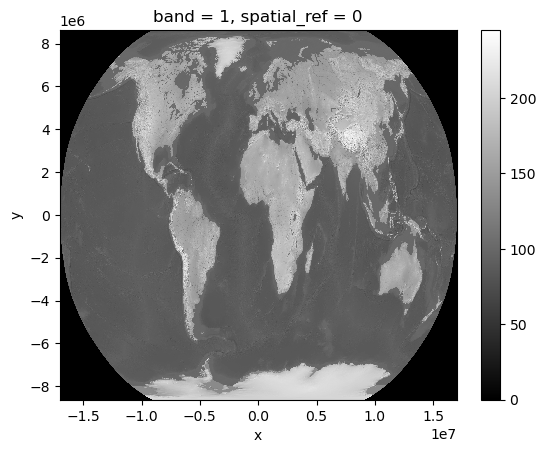

In [15]:
hillshade_coarsened_da.plot.imshow(cmap='gray')

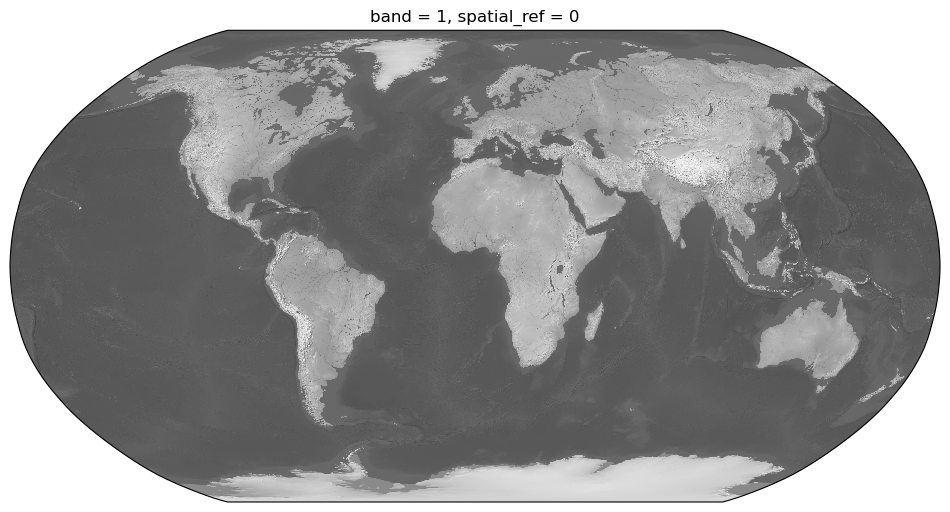

In [16]:
fig, ax = plt.subplots(figsize=(12, 7), subplot_kw=dict(projection=ccrs.Robinson()))
hillshade_coarsened_da.plot.imshow(ax=ax, cmap='gray', transform=ccrs.Robinson(), add_colorbar=False)

## clean up downloaded folder

In [17]:
shutil.rmtree("GRAY_HR_SR_OB_DR", ignore_errors=True)